In [33]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')
import time

In [34]:
def viphan_ham_the_tinhdien(x,y,z):
    global sigma, R, eps0
    dV = 1/(4*np.pi*eps0) * sigma * 1/np.sqrt(x**2+y**2+(z)**2)
    return dV

def tinh_MC_thetinhdien(z, N):
    global R
    tich_phan = 0
    for i in range(N):
        x  = np.random.uniform(-R, R)
        y  = np.random.uniform(-R, R)

        if x**2 + y**2 <= R**2: # chi lay nhung diem trong hinh tron
            dV = viphan_ham_the_tinhdien(x,y,z)
            tich_phan = tich_phan + dV
    
    dientichhinhvuong = (2*R)**2

    V = tich_phan * dientichhinhvuong / N

    return V

In [35]:
R = 1.0
sigma = 100
eps0 = 1.0

z = np.linspace(0.5*R, 5*R, 100)
V_MC = np.zeros(len(z))
V_exact = np.zeros(len(z))

N_MC = 50000

for i in range(len(z)):
    V_MC[i] = tinh_MC_thetinhdien(z[i], N_MC)
    V_exact[i] = sigma / (2*eps0) * (np.sqrt(R**2 + z[i]**2) - z[i])

In [36]:
def ghifile(d, V, filename):
    filename = f"{"KQ"}_{filename}.txt"
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"# Tinh the tinh dien bang MC va Riemann \n")
        file.write("#\n")
        file.write(f"# {'d':>20s} {'V':>20s}\n")
        for d_step in range(len(d)):
                file.write(f"  {d[d_step]:20.8e} {V[d_step]:20.8e}\n")

ghifile(z, V_MC, "bai6_MC")
ghifile(z, V_exact, "bai6_calculus")

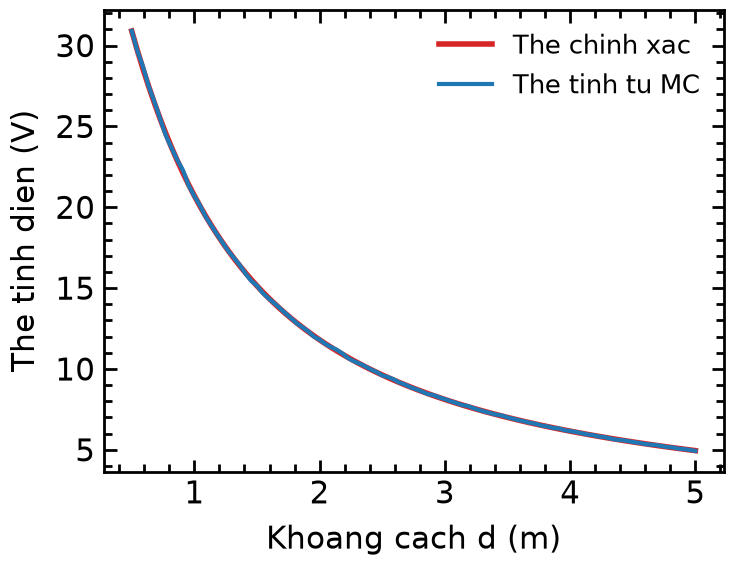

In [37]:
d_tinhdien, V_tinhdien = np.loadtxt("KQ_bai6_MC.txt", comments="#", unpack=True)
d_tinhdien_calculus, V_tinhdien_calculus = np.loadtxt("KQ_bai6_calculus.txt", comments="#", unpack=True)

plt.figure(figsize=(8,6))
plt.plot(d_tinhdien_calculus, V_tinhdien_calculus, label="The chinh xac", color="C1", lw = 4)
plt.plot(d_tinhdien, V_tinhdien, label="The tinh tu MC", color="C0", lw = 3)


plt.xlabel("Khoang cach d (m)")
plt.ylabel("The tinh dien (V)")
plt.legend()
plt.savefig("bai6_so_sanh_tinh_dien.png", dpi = 300)
plt.show()